<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_2_Alfaro_Badillo_Cruz_Perez_Rupit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Modelos Base y Regularización

Rúbrica: 20% Implementación correcta de Regresión Logística/GLM. Interpretación de coeficientes y justificación analítica del efecto de las penalizaciones Lasso y Ridge en su matriz de datos.


## Resumen de la programación realizada en este código
Se genera una visualización, así como las correlaciones de las diferentes variables para poder identificar posibles colinealidades.
1) Cálculo de correlaciones y Visualización de datos en
2)
3)

In [ ]:
# necesito saber que tan independientes o dependientes son mis variables entre si.
# Para ello necesito visualizar posibles correlaciones o relaciones estadisticas entre ellas.

# Dadas las graficas de abajo quiero diferenciar que variables son dependientes de otras, y ver como esto afecta al tipo de imputacion
# despues, normalizamos

In [24]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
import scipy.stats as stats
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
#from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
#from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso

Modelo en la base de datos PRSA_data_clean_scaled

In [2]:
# Importar la información  ya limpia y normalizada
df_clean = pd.read_csv("PRSA_data_clean_scaled.csv", sep='\t', encoding='utf-8')

In [3]:
display(df_clean.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,WIND_SPEED_lag5_scaled,WIND_SPEED_lag9_scaled,WIND_SPEED_lag13_scaled,WIND_SPEED_lag17_scaled,WIND_SPEED_lag21_scaled,WIND_SPEED_lag25_scaled,hour_sin_scaled,hour_cos_scaled,month_sin_scaled,month_cos_scaled
0,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,...,-0.464615,-0.446867,0.284782,0.011501,-0.216852,-0.443743,0.366439,1.365439,0.707518,1.220224
1,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,...,-0.446343,-0.428703,0.348794,0.075645,-0.152795,-0.380073,0.707398,1.224107,0.707518,1.220224
2,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,...,-0.428273,-0.446867,0.412807,0.158028,-0.088738,-0.343661,1.000186,0.999281,0.707518,1.220224


In [4]:
# Me doy cuenta que la columna FECHA y FECHA_SIN_H están como objetos y no como dates
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41756 entries, 0 to 41755
Data columns (total 90 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NO                       41756 non-null  int64  
 1   YEAR                     41756 non-null  int64  
 2   MONTH                    41756 non-null  int64  
 3   DAY                      41756 non-null  int64  
 4   HOUR                     41756 non-null  int64  
 5   PM25                     41756 non-null  float64
 6   DEWPOINT                 41756 non-null  int64  
 7   TEMP                     41756 non-null  float64
 8   PRESION                  41756 non-null  float64
 9   WIND_DIRECTION           41756 non-null  object 
 10  WIND_SPEED               41756 non-null  float64
 11  SNOW                     41756 non-null  int64  
 12  RAIN                     41756 non-null  int64  
 13  FECHA                    41756 non-null  object 
 14  FECHA_SIN_H           

In [5]:
# Se transforman las columnas de fechas a formato date.
df_clean["FECHA"] = pd.to_datetime(df_clean["FECHA"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df_clean["FECHA_SIN_H"] = pd.to_datetime(df_clean["FECHA_SIN_H"], format="%Y-%m-%d", errors="coerce")


In [6]:
df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR","FECHA", "FECHA_SIN_H" ]).describe()

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,...,WIND_SPEED_lag5_scaled,WIND_SPEED_lag9_scaled,WIND_SPEED_lag13_scaled,WIND_SPEED_lag17_scaled,WIND_SPEED_lag21_scaled,WIND_SPEED_lag25_scaled,hour_sin_scaled,hour_cos_scaled,month_sin_scaled,month_cos_scaled
count,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,41756.000000,...,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04
mean,98.612487,1.750599,12.401954,1016.442811,23.867276,0.055345,0.194870,0.113900,0.322924,0.348980,...,-6.534352e-17,5.173029e-17,1.565522e-16,4.628499e-17,1.361323e-17,6.398220e-17,-2.339775e-17,5.036896e-17,8.848602e-18,6.534352e-17
std,92.051369,14.433570,12.175096,10.300841,49.617972,0.778884,1.418182,0.317693,0.467599,0.476653,...,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-4.735485e-01,-4.742138e-01,-4.741636e-01,-4.741910e-01,-4.730815e-01,-4.710011e-01,-1.413161e+00,-1.415801e+00,-1.422073e+00,-1.408571e+00
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-4.463429e-01,-4.468668e-01,-4.467589e-01,-4.467300e-01,-4.456576e-01,-4.437429e-01,-9.990964e-01,-1.001439e+00,-7.122095e-01,-1.219832e+00
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-3.736590e-01,-3.738054e-01,-3.735435e-01,-3.733639e-01,-3.723908e-01,-3.711222e-01,5.447026e-04,-1.078595e-03,-2.345648e-03,1.962625e-04
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000,0.000000,1.000000,1.000000,...,-3.785166e-02,-3.645763e-02,-3.548448e-02,-3.460941e-02,-3.409450e-02,-3.466679e-02,1.000186e+00,9.992814e-01,7.075182e-01,1.220224e+00
max,994.000000,28.000000,42.000000,1046.000000,565.490000,27.000000,36.000000,1.000000,1.000000,1.000000,...,1.020874e+01,9.524381e+00,9.545512e+00,9.566099e+00,1.150236e+01,1.143208e+01,1.414251e+00,1.413644e+00,1.417382e+00,1.408963e+00


DEWPOINT                  0.171436
DEWPOINT_scaled           0.171436
DEWPOINT_lag1             0.169045
DEWPOINT_lag1_scaled      0.169045
WIND_DIRECTION_cv         0.156200
                            ...   
WIND_SPEED_lag5          -0.232563
WIND_SPEED_scaled        -0.247782
WIND_SPEED               -0.247782
WIND_SPEED_lag1          -0.247817
WIND_SPEED_lag1_scaled   -0.247817
Name: PM25, Length: 85, dtype: float64


/tmp/ipykernel_3325/160559563.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_pm25_sorted.values, y=corr_pm25_sorted.index, palette="coolwarm")


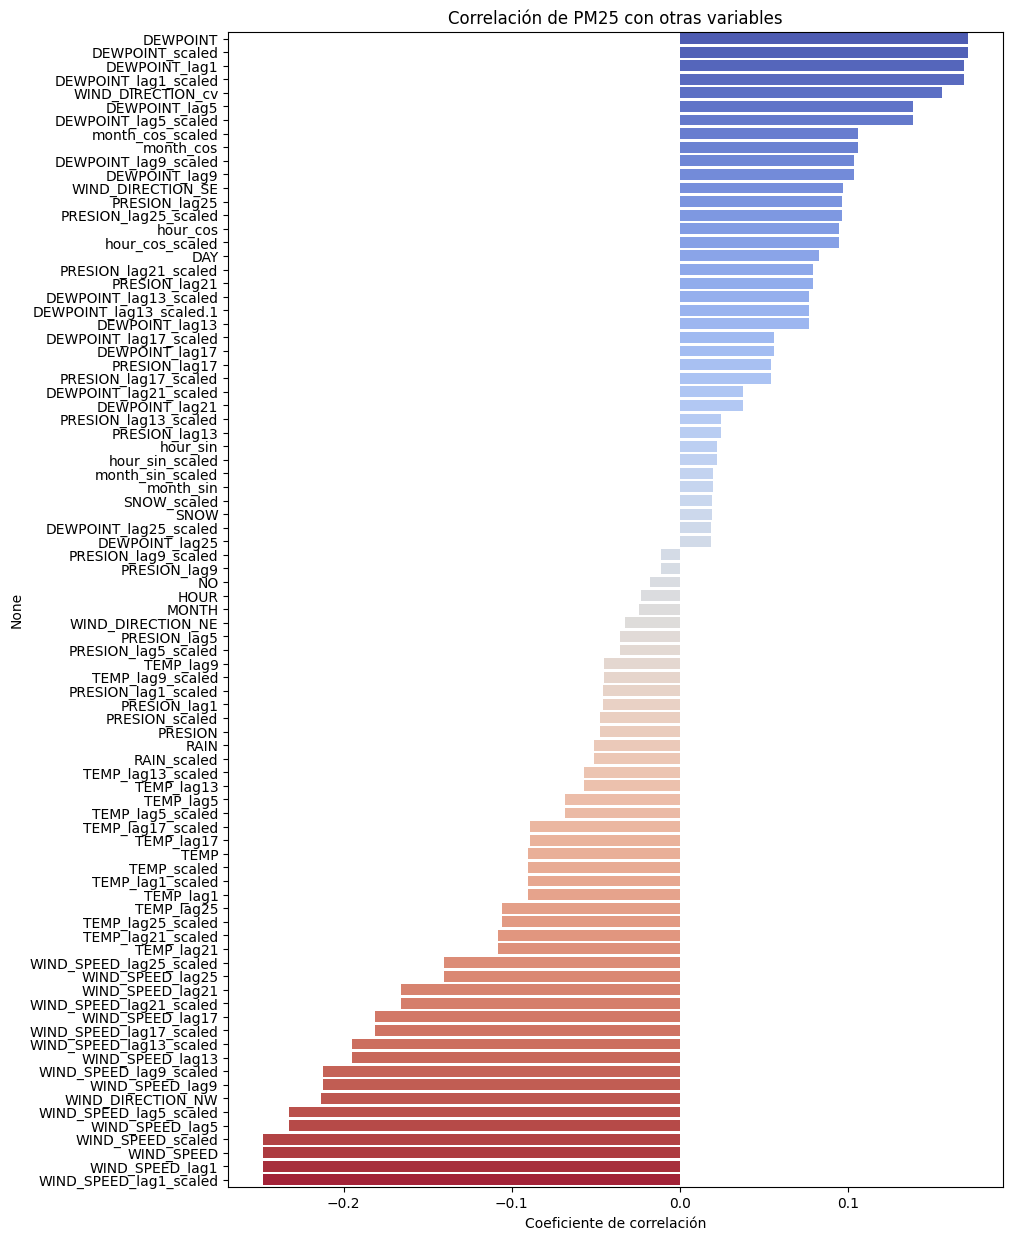

In [7]:
# 1. Seleccionar solo las columnas numéricas
# df_num = df_clean.select_dtypes(include=["float64", "int64"]) # Este código no fue útil ya que casi todas las variables son numéricas

# 1. Eliminar las columnas que no son para la regresión
#df_clean_num = df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H"])
df_clean_num = df_clean.drop(columns=[ "YEAR", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H"])

# 2. Calcular la matriz de correlación
corr_matrix = df_clean_num.corr()

# 2. Extraer solo la correlación con PM25
corr_pm25 = corr_matrix["PM25"].drop("PM25")  # quitamos la correlación consigo misma

# 3. Ordenar las correlaciones de mayor a menor
corr_pm25_sorted = corr_pm25.sort_values(ascending=False)

# 4. Mostrar resultados
print(corr_pm25_sorted)

# 5. Graficar como barra horizontal
plt.figure(figsize=(10, 15))
sns.barplot(x=corr_pm25_sorted.values, y=corr_pm25_sorted.index, palette="coolwarm")
plt.title("Correlación de PM25 con otras variables")
plt.xlabel("Coeficiente de correlación")
plt.show()

#CÓDIGO PARA TABLA DE CORRELACIONES COMPLETA
# 3. Graficar con Seaborn
#plt.figure(figsize=(12, 8))  # ajusta tamaño según lo necesites
#sns.heatmap(corr_matrix,
#            annot=True,        # muestra valores numéricos
#            fmt=".2f",         # formato de decimales
#            cmap="coolwarm",   # paleta de colores
#            cbar=True)

#plt.title("Matriz de correlación de variables numéricas")
#plt.title("Matriz de correlación de variables numéricas", fontsize=14)
#plt.show()

#INTERPRETACIÓN: la variable pm2.5 tiene correlaciones:
# Negativas:
# -0.25 Wind_speed que puede hacer sentido porque dispesa las partículas
# -0.21 Wind_direction_NW

#Positivas:
# 0.17 con Dewpoint (rocío), aunque hubiera esperado una relación negativa
# 0.16 con Wind_Direction_cv

# Por su parte las variables con la "más alta correlación" con pm2.5, correlacionan más fuertemente entre ellas, como por ejemplo:
# Wind_speed  y Wind_direction_NW tienen una correlación de 0.36 :s o Wind_speed y Dewpoint -0.29.

In [8]:
# Expotar .csv
#DFs con los las correlaciones de PM25"
corr_pm25_sorted.to_csv("PRSA_data_correl_PM25.csv", sep='\t', encoding='utf-8', index=False, header=True)

In [9]:
#Buscamos el mejor lagueo
corr_ordenadas = corr_pm25.abs().sort_values(ascending=False)
print(corr_ordenadas)

WIND_SPEED_lag1           0.247817
WIND_SPEED_lag1_scaled    0.247817
WIND_SPEED                0.247782
WIND_SPEED_scaled         0.247782
WIND_SPEED_lag5           0.232563
                            ...   
DEWPOINT_lag25_scaled     0.018713
DEWPOINT_lag25            0.018713
NO                        0.017693
PRESION_lag9              0.011065
PRESION_lag9_scaled       0.011065
Name: PM25, Length: 85, dtype: float64


In [10]:
#Filtro las variables con las que nos vamos a quedar para hacer las regresiones
df_clean_mod = df_clean[["PM25", "YEAR", "month_sin_scaled", "month_cos_scaled","hour_sin_scaled","hour_cos_scaled", "WIND_DIRECTION_NW", "WIND_DIRECTION_cv", "WIND_DIRECTION_SE", "WIND_DIRECTION_NE", "WIND_SPEED_lag1_scaled", "DEWPOINT_scaled", "TEMP_lag21_scaled", "RAIN_scaled", "SNOW_scaled", "PRESION_scaled"]]
print(df_clean_mod.head(3))


    PM25  YEAR  month_sin_scaled  month_cos_scaled  hour_sin_scaled  \
0  148.0  2010          0.707518          1.220224         0.366439   
1  159.0  2010          0.707518          1.220224         0.707398   
2  181.0  2010          0.707518          1.220224         1.000186   

   hour_cos_scaled  WIND_DIRECTION_NW  WIND_DIRECTION_cv  WIND_DIRECTION_SE  \
0         1.365439                0.0                0.0                1.0   
1         1.224107                0.0                0.0                1.0   
2         0.999281                0.0                0.0                1.0   

   WIND_DIRECTION_NE  WIND_SPEED_lag1_scaled  DEWPOINT_scaled  \
0                0.0               -0.445273        -1.160544   
1                0.0               -0.427307        -0.883409   
2                0.0               -0.409341        -0.606274   

   TEMP_lag21_scaled  RAIN_scaled  SNOW_scaled  PRESION_scaled  
0          -2.002604     -0.13741    -0.071058        0.345334  
1      

In [11]:
# Expotar .csv de la información para modelar
df_clean_mod.to_csv("PRSA_data_clean_for_modeling.csv", sep='\t', encoding='utf-8', index=False, header=True)

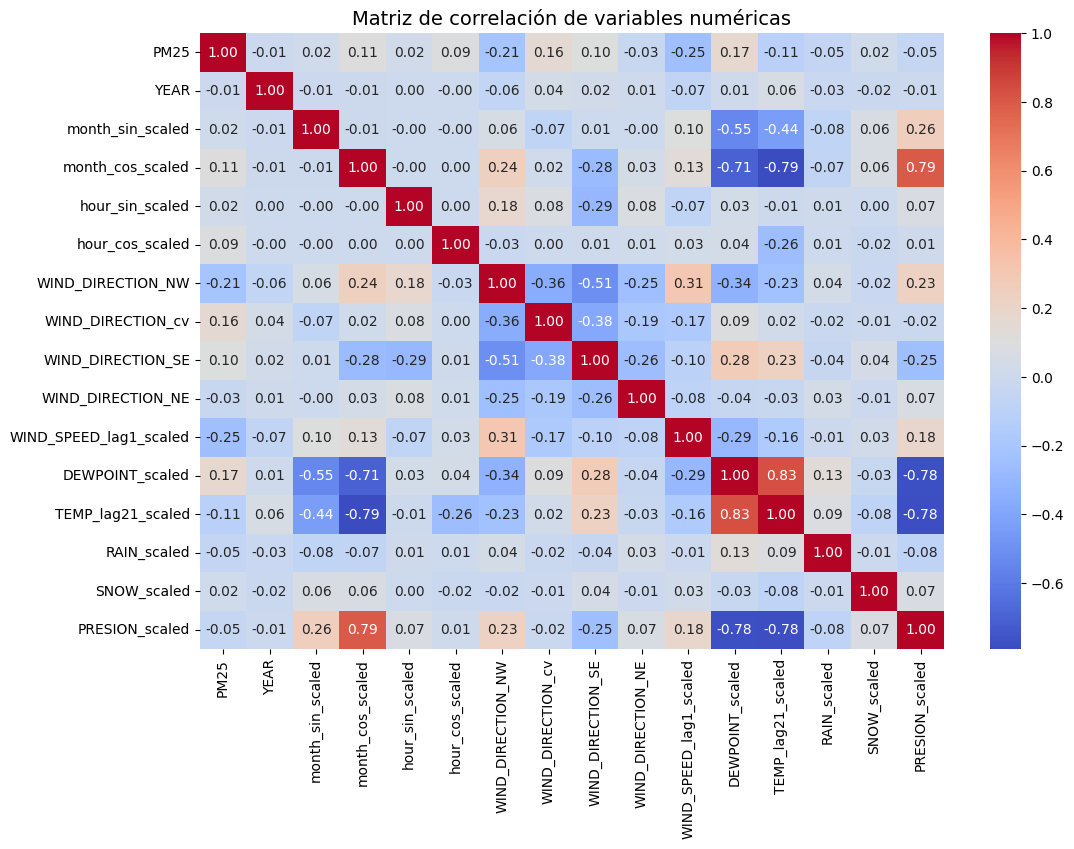

In [12]:
#CÓDIGO PARA TABLA DE CORRELACIONES COMPLETA

# 1. Seleccionar solo las columnas numéricas
df_clean_num = df_clean_mod.select_dtypes(include=["float64", "int64"])

# 2. Calcular la matriz de correlación
corr_matrix = df_clean_num.corr()

# 3. Graficar con Seaborn
plt.figure(figsize=(12, 8))  # ajusta tamaño según lo necesites
sns.heatmap(corr_matrix,
            annot=True,        # muestra valores numéricos
            fmt=".2f",         # formato de decimales
            cmap="coolwarm",   # paleta de colores
            cbar=True)

plt.title("Matriz de correlación de variables numéricas", fontsize=14)
plt.show()

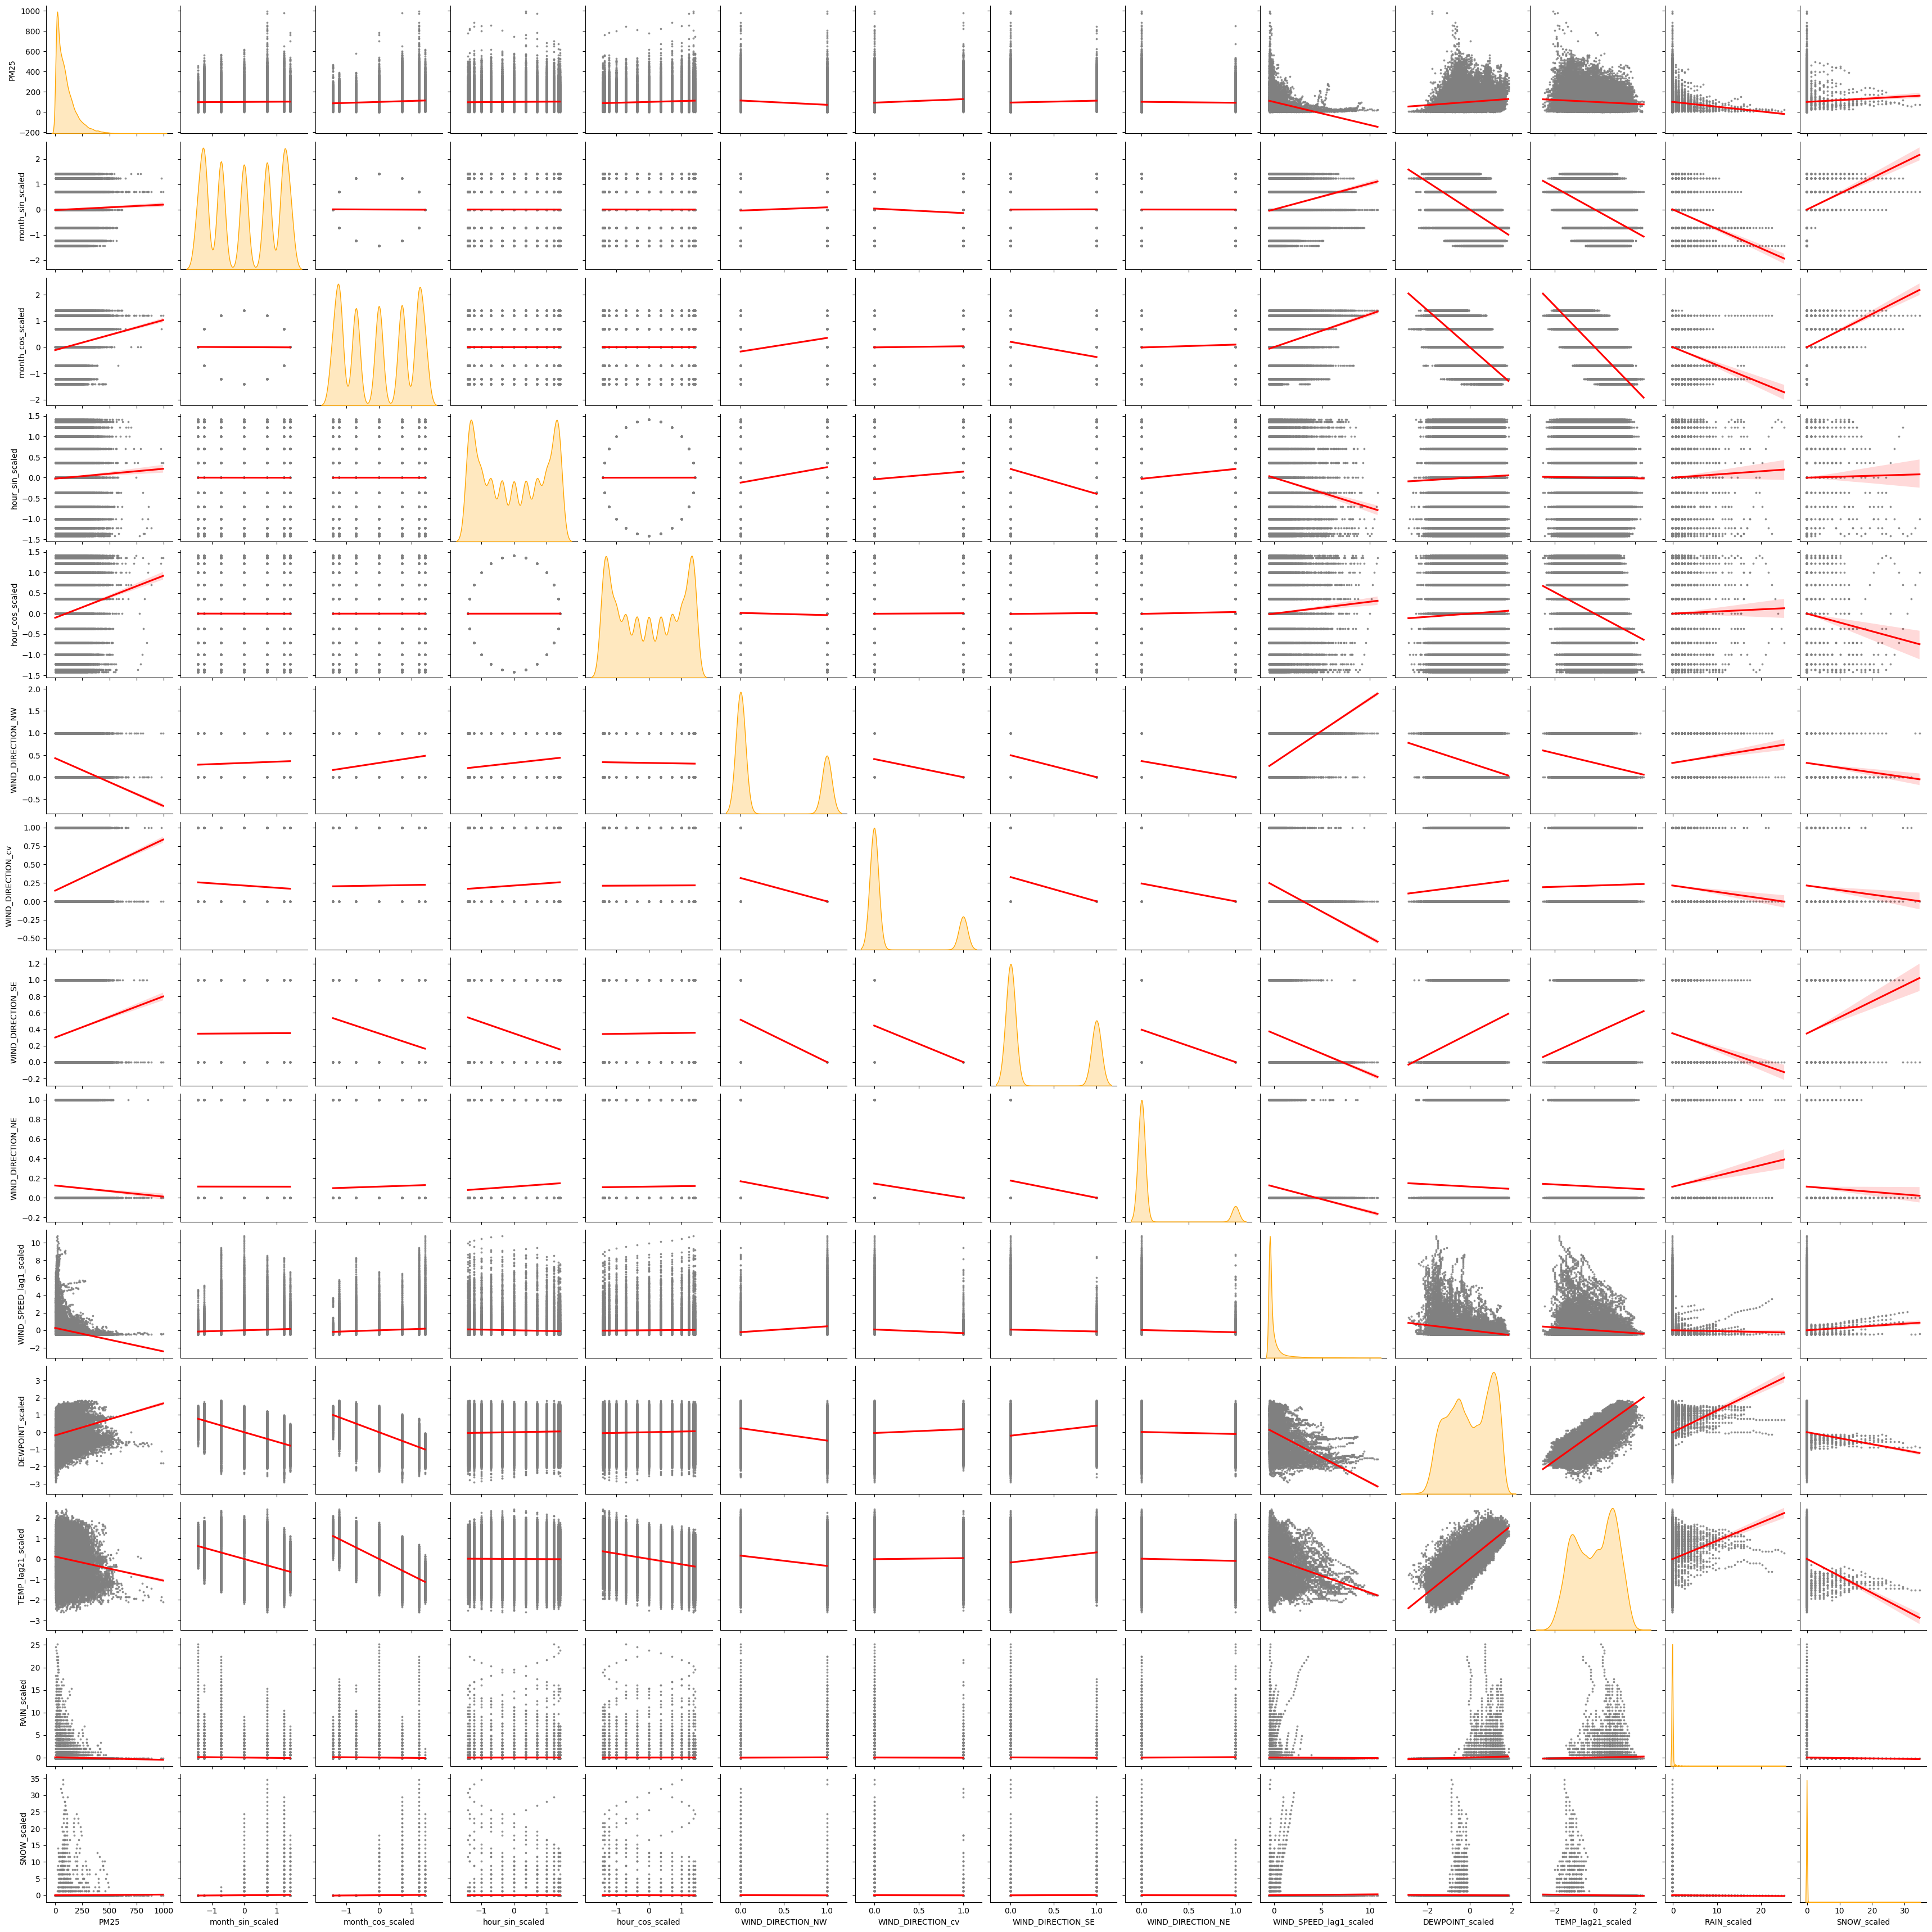

In [ ]:
# CUIDADO! Estas líneas de código tardan 7 minutos aprox en correr
# Crear gráficos que muestren las correlaciones y distribuciones
#plt.figure(figsize=(10, 6))   # ajusta ancho y alto según

# Eliminar las columnas que no son para la regresión
df_clean_num = df_clean_mod.drop(columns=["YEAR"])

sns.pairplot(
    df_clean_num,
    diag_kws={"color": "orange"},
    diag_kind='kde',
    kind="reg",
    plot_kws={"scatter_kws":{"color":"grey", "s":3},  "line_kws": {"color": "red"}}, #aqui defines el tamaño de los puntos s:3
    )
plt.show()

In [13]:
#Modelo de Regresión Lineal - Hicimos esta regresión para tener una base comparativa con el resto de los modelos.
# Inicialmente hicimos la versión 1 con las variables sin modificar y después les hicimos diferentes transformaciones para ver el efecto retardado en Pm2.5

#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_squared_error, mean_absolute_error
#from sklearn.model_selection import train_test_split

y = df_clean_mod["PM25"]
X = df_clean_mod.drop(columns=["PM25"])
# Poner y quitar las variables que necesites...
# "PM25", "NO", "YEAR", "month_sin_scaled", "month_cos_scaled","hour_sin_scaled","hour_cos_scaled",
#"WIND_DIRECTION_NW", "WIND_DIRECTION_cv", "WIND_DIRECTION_SE", "WIND_DIRECTION_NE", "WIND_SPEED_lag1_scaled",
#"DEWPOINT_scaled", "TEMP_lag21_scaled", "RAIN_scaled", "SNOW_scaled"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Ajusta el modelo con los datos de entrenamiento
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Genea valores estimados o predicciones
y_pred = lin_reg.predict(X_test)

#Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lin_reg.coef_
})
print(coeficientes)

MSE: 5095.438173261994
MAE: 52.04345384855706
R²: 0.3945473184974596
                  Variable  Coeficiente
0                     YEAR    -0.489360
1         month_sin_scaled    53.732557
2         month_cos_scaled    76.644030
3          hour_sin_scaled    -0.044210
4          hour_cos_scaled    -5.468706
5        WIND_DIRECTION_NW    -9.463642
6        WIND_DIRECTION_cv    10.765014
7        WIND_DIRECTION_SE     2.532143
8        WIND_DIRECTION_NE    -3.833515
9   WIND_SPEED_lag1_scaled    -5.228511
10         DEWPOINT_scaled   114.923900
11       TEMP_lag21_scaled   -36.874073
12             RAIN_scaled    -7.591953
13             SNOW_scaled    -4.369246
14          PRESION_scaled   -16.059400


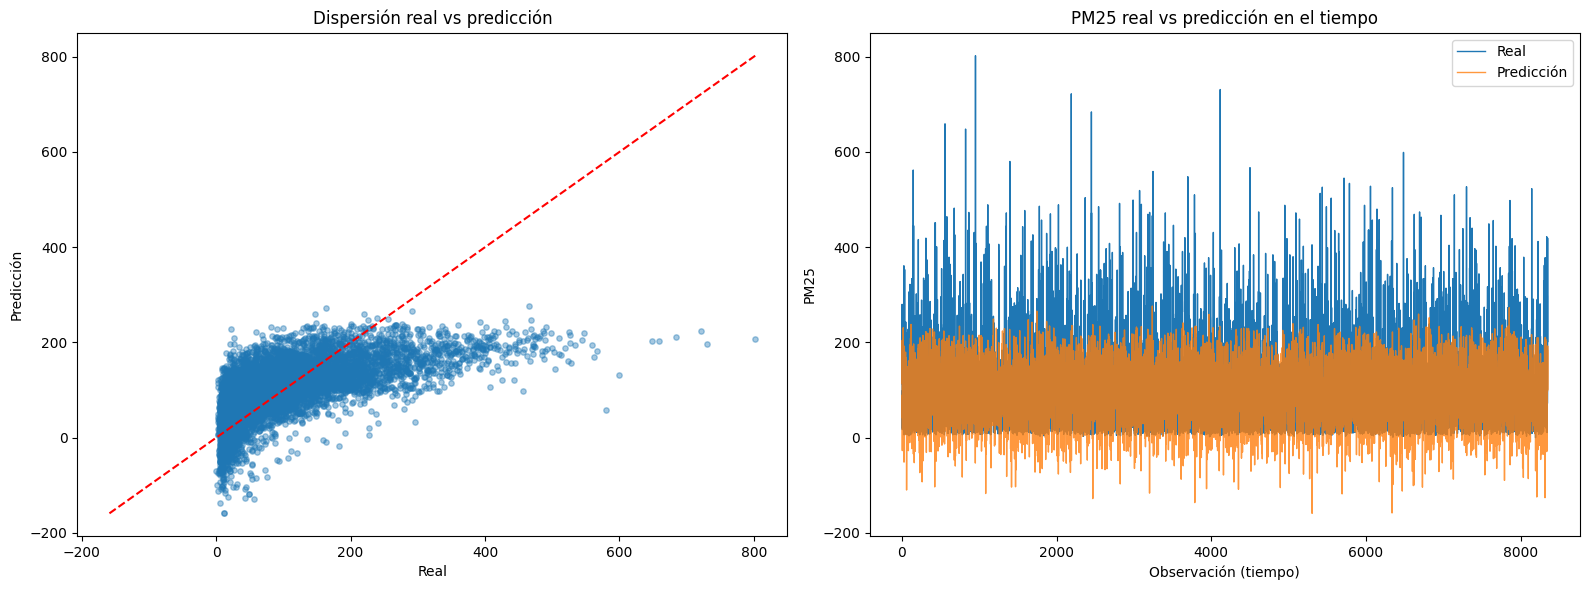

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1. Dispersión real vs predicción
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color='red', linestyle='--')
axes[0].set_title('Dispersión real vs predicción')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Predicción')

# 2. Serie temporal real vs predicción
axes[1].plot(y_test.values, label='Real', linewidth=1)
axes[1].plot(y_pred, label='Predicción', linewidth=1, alpha=0.8)
axes[1].set_xlabel('Observación (tiempo)')
axes[1].set_ylabel('PM25')
axes[1].set_title('PM25 real vs predicción en el tiempo')
axes[1].legend()

plt.tight_layout()
plt.show()

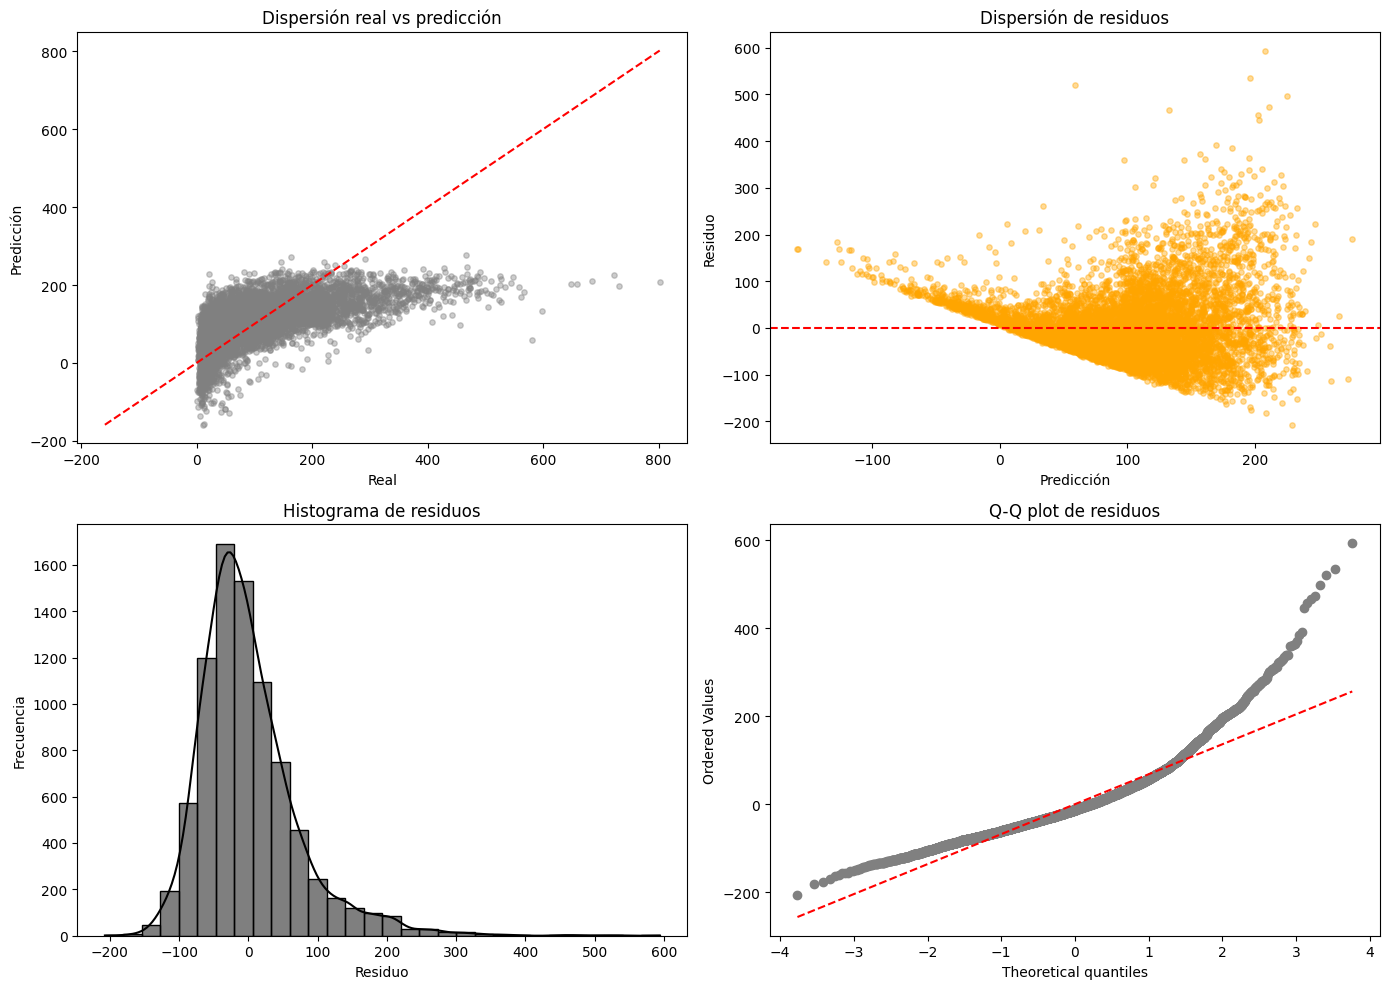

In [15]:
#import matplotlib.pyplot as plt
#import seaborn as sns
import scipy.stats as stats

# 1. Dispersión valores reales vs predicción
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.scatter(y_test, y_pred, alpha=0.4, s=15, color="grey")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.title("Dispersión real vs predicción")
plt.xlabel("Real")
plt.ylabel("Predicción")

# 2. Dispersión de residuos
residuos = y_test - y_pred
plt.subplot(2,2,2)
plt.scatter(y_pred, residuos, alpha=0.4, s=15, color="orange")
plt.axhline(0, color='red', linestyle='--')
plt.title("Dispersión de residuos")
plt.xlabel("Predicción")
plt.ylabel("Residuo")

# 3. Histograma de residuos
plt.subplot(2,2,3)
sns.histplot(residuos, bins=30, kde=True, color="black")
plt.title("Histograma de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

# 4. Q-Q plot
plt.subplot(2,2,4)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos")
# Cambiar color de los elementos
plt.gca().get_lines()[0].set_color("grey")   # puntos
plt.gca().get_lines()[1].set_color("red")    # línea de referencia
plt.gca().get_lines()[1].set_linestyle('--')    # línea de referencia


plt.tight_layout()
plt.show()

Los coeficientes indican la relación entre las variables meteorológicas y la concentración de PM2.5. Coeficientes positivos implican un aumento en la contaminación al aumentar la variable, mientras que negativos sugieren una relación inversa.

Modelo RIDGE

In [ ]:
Ridge penaliza el tamaño de los coeficientes reduciéndolos, pero sin llevarlos a cero. Esto ayuda a estabilizar el modelo en presencia de multicolinealidad, mejorando la generalización.

In [16]:
#Modelo de Regresión Ridge
#from sklearn.linear_model import Ridge
y = df_clean_mod["PM25"]
X = df_clean_mod.drop(columns=["PM25"])

# División entrenamiento prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Se ocupa también en la lineal, pero para que el cpodigo sea autocontenido también se copia aqui.

#Modelo
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

#Predicciones
y_pred_ridge = ridge.predict(X_test)

#Evaluación del modelo
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred))

#Coeficientes
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": ridge.coef_
}).sort_values(by="Coeficiente", ascending=False)
print(coeficientes)

Ridge MSE: 5095.39638279553
Ridge MAE: 52.04205710412571
R²: 0.3945473184974596
                  Variable  Coeficiente
10         DEWPOINT_scaled   114.887114
2         month_cos_scaled    76.615399
1         month_sin_scaled    53.710465
6        WIND_DIRECTION_cv    10.766629
7        WIND_DIRECTION_SE     2.536232
3          hour_sin_scaled    -0.042591
0                     YEAR    -0.489640
8        WIND_DIRECTION_NE    -3.835190
13             SNOW_scaled    -4.367313
9   WIND_SPEED_lag1_scaled    -5.232694
4          hour_cos_scaled    -5.467468
12             RAIN_scaled    -7.590441
5        WIND_DIRECTION_NW    -9.467671
14          PRESION_scaled   -16.058913
11       TEMP_lag21_scaled   -36.875680


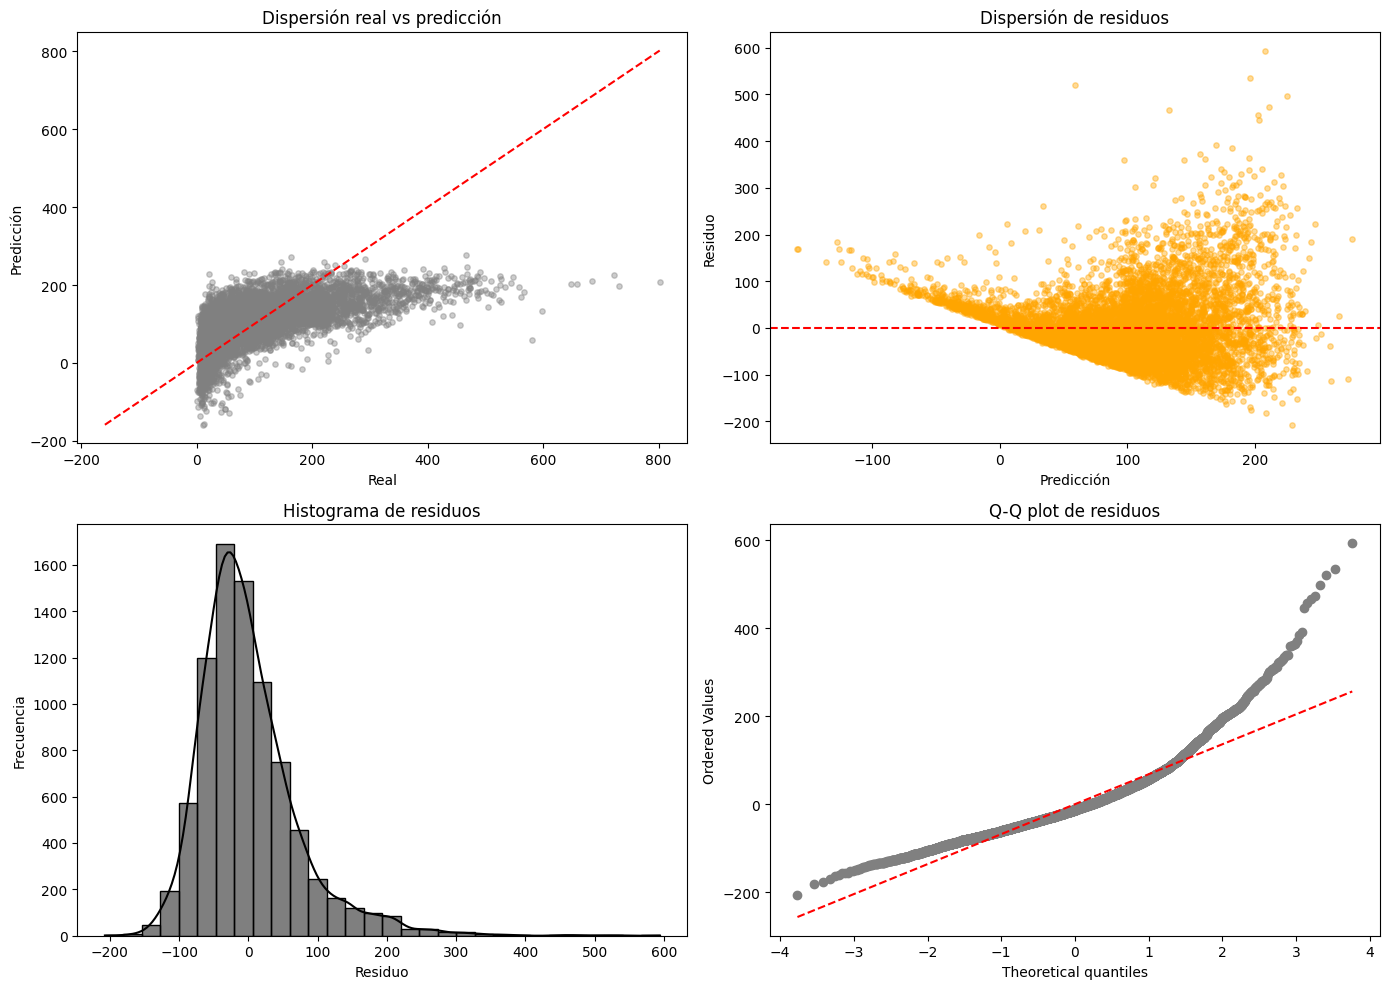

In [17]:
#import matplotlib.pyplot as plt
#import seaborn as sns
import scipy.stats as stats

# 1. Dispersión valores reales vs predicción
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.scatter(y_test, y_pred, alpha=0.4, s=15, color="grey")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.title("Dispersión real vs predicción")
plt.xlabel("Real")
plt.ylabel("Predicción")

# 2. Dispersión de residuos
residuos = y_test - y_pred
plt.subplot(2,2,2)
plt.scatter(y_pred, residuos, alpha=0.4, s=15, color="orange")
plt.axhline(0, color='red', linestyle='--')
plt.title("Dispersión de residuos")
plt.xlabel("Predicción")
plt.ylabel("Residuo")

# 3. Histograma de residuos
plt.subplot(2,2,3)
sns.histplot(residuos, bins=30, kde=True, color="black")
plt.title("Histograma de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

# 4. Q-Q plot
plt.subplot(2,2,4)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos")
# Cambiar color de los elementos
plt.gca().get_lines()[0].set_color("grey")   # puntos
plt.gca().get_lines()[1].set_color("red")    # línea de referencia
plt.gca().get_lines()[1].set_linestyle('--')    # línea de referencia


plt.tight_layout()
plt.show()

Modelo LASSO

In [20]:
#Modelos de regresión Lasso // Sólo con las variables Seleccionadas basadas en su correlción: df_clean_mod
#from sklearn.linear_model import Lasso

from sklearn.linear_model import Lasso

y = df_clean_mod["PM25"]
X = df_clean_mod.drop(columns=["PM25"])

# División entrenamiento prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Se ocupa también en la lineal, pero para que el cpodigo sea autocontenido también se copia aqui.

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("Lasso R²:", r2_score(y_test, y_pred_lasso))

#Coeficientes
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lasso.coef_
}).sort_values(by="Coeficiente", ascending=False)
print(coeficientes)

Lasso MSE: 5096.136093419026
Lasso MAE: 52.00426872374014
Lasso R²: 0.394464389882455
                  Variable  Coeficiente
10         DEWPOINT_scaled   113.837324
2         month_cos_scaled    75.838691
1         month_sin_scaled    53.171608
6        WIND_DIRECTION_cv     8.148376
7        WIND_DIRECTION_SE     0.067089
3          hour_sin_scaled    -0.001019
0                     YEAR    -0.451079
13             SNOW_scaled    -4.185074
4          hour_cos_scaled    -5.175331
8        WIND_DIRECTION_NE    -5.309393
9   WIND_SPEED_lag1_scaled    -5.324984
12             RAIN_scaled    -7.486348
5        WIND_DIRECTION_NW   -11.494980
14          PRESION_scaled   -15.630984
11       TEMP_lag21_scaled   -36.297759


In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns
import scipy.stats as stats

# 1. Dispersión valores reales vs predicción
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.scatter(y_test, y_pred, alpha=0.4, s=15, color="grey")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.title("Dispersión real vs predicción")
plt.xlabel("Real")
plt.ylabel("Predicción")

# 2. Dispersión de residuos
residuos = y_test - y_pred
plt.subplot(2,2,2)
plt.scatter(y_pred, residuos, alpha=0.4, s=15, color="orange")
plt.axhline(0, color='red', linestyle='--')
plt.title("Dispersión de residuos")
plt.xlabel("Predicción")
plt.ylabel("Residuo")

# 3. Histograma de residuos
plt.subplot(2,2,3)
sns.histplot(residuos, bins=30, kde=True, color="black")
plt.title("Histograma de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

# 4. Q-Q plot
plt.subplot(2,2,4)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos")
# Cambiar color de los elementos
plt.gca().get_lines()[0].set_color("grey")   # puntos
plt.gca().get_lines()[1].set_color("red")    # línea de referencia
plt.gca().get_lines()[1].set_linestyle('--')    # línea de referencia


plt.tight_layout()
plt.show()

In [25]:
df_clean.columns

Index(['NO', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'PM25', 'DEWPOINT', 'TEMP',
       'PRESION', 'WIND_DIRECTION', 'WIND_SPEED', 'SNOW', 'RAIN', 'FECHA',
       'FECHA_SIN_H', 'WIND_DIRECTION_NE', 'WIND_DIRECTION_NW',
       'WIND_DIRECTION_SE', 'WIND_DIRECTION_cv', 'DEWPOINT_lag1',
       'DEWPOINT_lag5', 'DEWPOINT_lag9', 'DEWPOINT_lag13', 'DEWPOINT_lag17',
       'DEWPOINT_lag21', 'DEWPOINT_lag25', 'TEMP_lag1', 'TEMP_lag5',
       'TEMP_lag9', 'TEMP_lag13', 'TEMP_lag17', 'TEMP_lag21', 'TEMP_lag25',
       'PRESION_lag1', 'PRESION_lag5', 'PRESION_lag9', 'PRESION_lag13',
       'PRESION_lag17', 'PRESION_lag21', 'PRESION_lag25', 'WIND_SPEED_lag1',
       'WIND_SPEED_lag5', 'WIND_SPEED_lag9', 'WIND_SPEED_lag13',
       'WIND_SPEED_lag17', 'WIND_SPEED_lag21', 'WIND_SPEED_lag25', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'DEWPOINT_scaled', 'TEMP_scaled',
       'PRESION_scaled', 'WIND_SPEED_scaled', 'SNOW_scaled', 'RAIN_scaled',
       'DEWPOINT_lag1_scaled', 'DEWPOINT_lag5_scaled

In [31]:
#Modelos de regresión Lasso // Con todas las variables, lags y escalados para que el modelo seleccione :
#from sklearn.linear_model import Lasso
#from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

# 1. Seleccionar solo las columnas numéricas
df_clean_num_mod = df_clean.select_dtypes(include=["float64", "int64"])
df_clean_num_mod = df_clean_num_mod.drop(columns=['NO', 'YEAR', 'MONTH', 'DAY', 'HOUR','DEWPOINT', 'TEMP',
                                         'PRESION',  'WIND_SPEED', 'SNOW', 'RAIN', 'DEWPOINT_lag1', 'DEWPOINT_lag5', 'DEWPOINT_lag9', 'DEWPOINT_lag13',
                                         'DEWPOINT_lag17','DEWPOINT_lag21', 'DEWPOINT_lag25', 'TEMP_lag1', 'TEMP_lag5',
                                         'TEMP_lag9', 'TEMP_lag13', 'TEMP_lag17', 'TEMP_lag21', 'TEMP_lag25', 'PRESION_lag1',
                                         'PRESION_lag5', 'PRESION_lag9', 'PRESION_lag13','PRESION_lag17', 'PRESION_lag21',
                                         'PRESION_lag25', 'WIND_SPEED_lag1', 'WIND_SPEED_lag5', 'WIND_SPEED_lag9',
                                         'WIND_SPEED_lag13','WIND_SPEED_lag17', 'WIND_SPEED_lag21', 'WIND_SPEED_lag25',
                                         ]) #quitar las columnas no escaladas...estas se quitaron en el paso anterior:'WIND_DIRECTION', 'FECHA','FECHA_SIN_H',
y = df_clean_num_mod["PM25"]
X = df_clean_num_mod.drop(columns=["PM25"])

# División entrenamiento prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Se ocupa también en la lineal, pero para que el cpodigo sea autocontenido también se copia aqui.

lasso_cv = LassoCV(alphas=[0.01, 0.1, 0.5, 1, 5], max_iter=10000, cv=5) # más iteraciones y cambio - búsqueda de ajuste
lasso_cv.fit(X_train, y_train)
print("Mejor alpha:", lasso_cv.alpha_)

y_pred_lasso2 = lasso_cv.predict(X_test)

print("Lasso2 MSE:", mean_squared_error(y_test, y_pred_lasso2))
print("Lasso2 MAE:", mean_absolute_error(y_test, y_pred_lasso2))
print("Lasso2 R²:", r2_score(y_test, y_pred_lasso2))

#Coeficientes
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lasso_cv.coef_
}).sort_values(by="Coeficiente", ascending=False)
print(coeficientes)

Mejor alpha: 0.01
Lasso2 MSE: 4942.153181205455
Lasso2 MAE: 50.91868730168671
Lasso2 R²: 0.4127610238391758
                   Variable  Coeficiente
8           DEWPOINT_scaled    66.312401
46         month_cos_scaled    61.977077
45         month_sin_scaled    44.878789
14     DEWPOINT_lag1_scaled    42.385081
35     PRESION_lag25_scaled    28.633304
15     DEWPOINT_lag5_scaled    13.068854
30      PRESION_lag5_scaled     8.295201
3         WIND_DIRECTION_cv     7.365806
32     PRESION_lag13_scaled     7.266916
24         TEMP_lag9_scaled     5.188737
31      PRESION_lag9_scaled     5.093970
16     DEWPOINT_lag9_scaled     3.899097
44          hour_cos_scaled     3.688078
11        WIND_SPEED_scaled     3.245613
17    DEWPOINT_lag13_scaled     0.896015
2         WIND_DIRECTION_SE     0.080141
5                  hour_cos     0.000000
4                  hour_sin    -0.000000
39  WIND_SPEED_lag13_scaled    -0.000000
18  DEWPOINT_lag13_scaled.1     0.000000
6                 month_sin    

In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns
import scipy.stats as stats

# 1. Dispersión valores reales vs predicción
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.scatter(y_test, y_pred, alpha=0.4, s=15, color="grey")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.title("Dispersión real vs predicción")
plt.xlabel("Real")
plt.ylabel("Predicción")

# 2. Dispersión de residuos
residuos = y_test - y_pred
plt.subplot(2,2,2)
plt.scatter(y_pred, residuos, alpha=0.4, s=15, color="orange")
plt.axhline(0, color='red', linestyle='--')
plt.title("Dispersión de residuos")
plt.xlabel("Predicción")
plt.ylabel("Residuo")

# 3. Histograma de residuos
plt.subplot(2,2,3)
sns.histplot(residuos, bins=30, kde=True, color="black")
plt.title("Histograma de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

# 4. Q-Q plot
plt.subplot(2,2,4)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos")
# Cambiar color de los elementos
plt.gca().get_lines()[0].set_color("grey")   # puntos
plt.gca().get_lines()[1].set_color("red")    # línea de referencia
plt.gca().get_lines()[1].set_linestyle('--')    # línea de referencia


plt.tight_layout()
plt.show()

In [ ]:
#Variables eliminadas
coef_lasso = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lasso.coef_
})

print(coef_lasso)


Interpretación (importantísima)

Lasso introduce una penalización L1 que puede llevar ciertos coeficientes exactamente a cero, realizando una selección automática de variables. Esto simplifica el modelo y mejora su interpretabilidad, especialmente útil cuando existen variables irrelevantes o redundantes.

In [ ]:
# Comparación de modelos
results = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'MSE': [
        mse,
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    'MAE': [
        mae,
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ]
})

print(results)


Modelo Logístico en la base de datos PRSA_data_Clean

Se consideró un modelo que indique la probabilidad de que de un alto nivel de contaminación o no

# **Código No utilizado**

Mientras que la regresión lineal proporciona un modelo interpretable, su desempeño puede deteriorarse ante multicolinealidad. Ridge mejora la estabilidad del modelo, mientras que Lasso introduce parsimonia al eliminar variables irrelevantes, lo cual puede resultar en mejores modelos explicables en contextos reales.

<Figure size 1000x600 with 0 Axes>

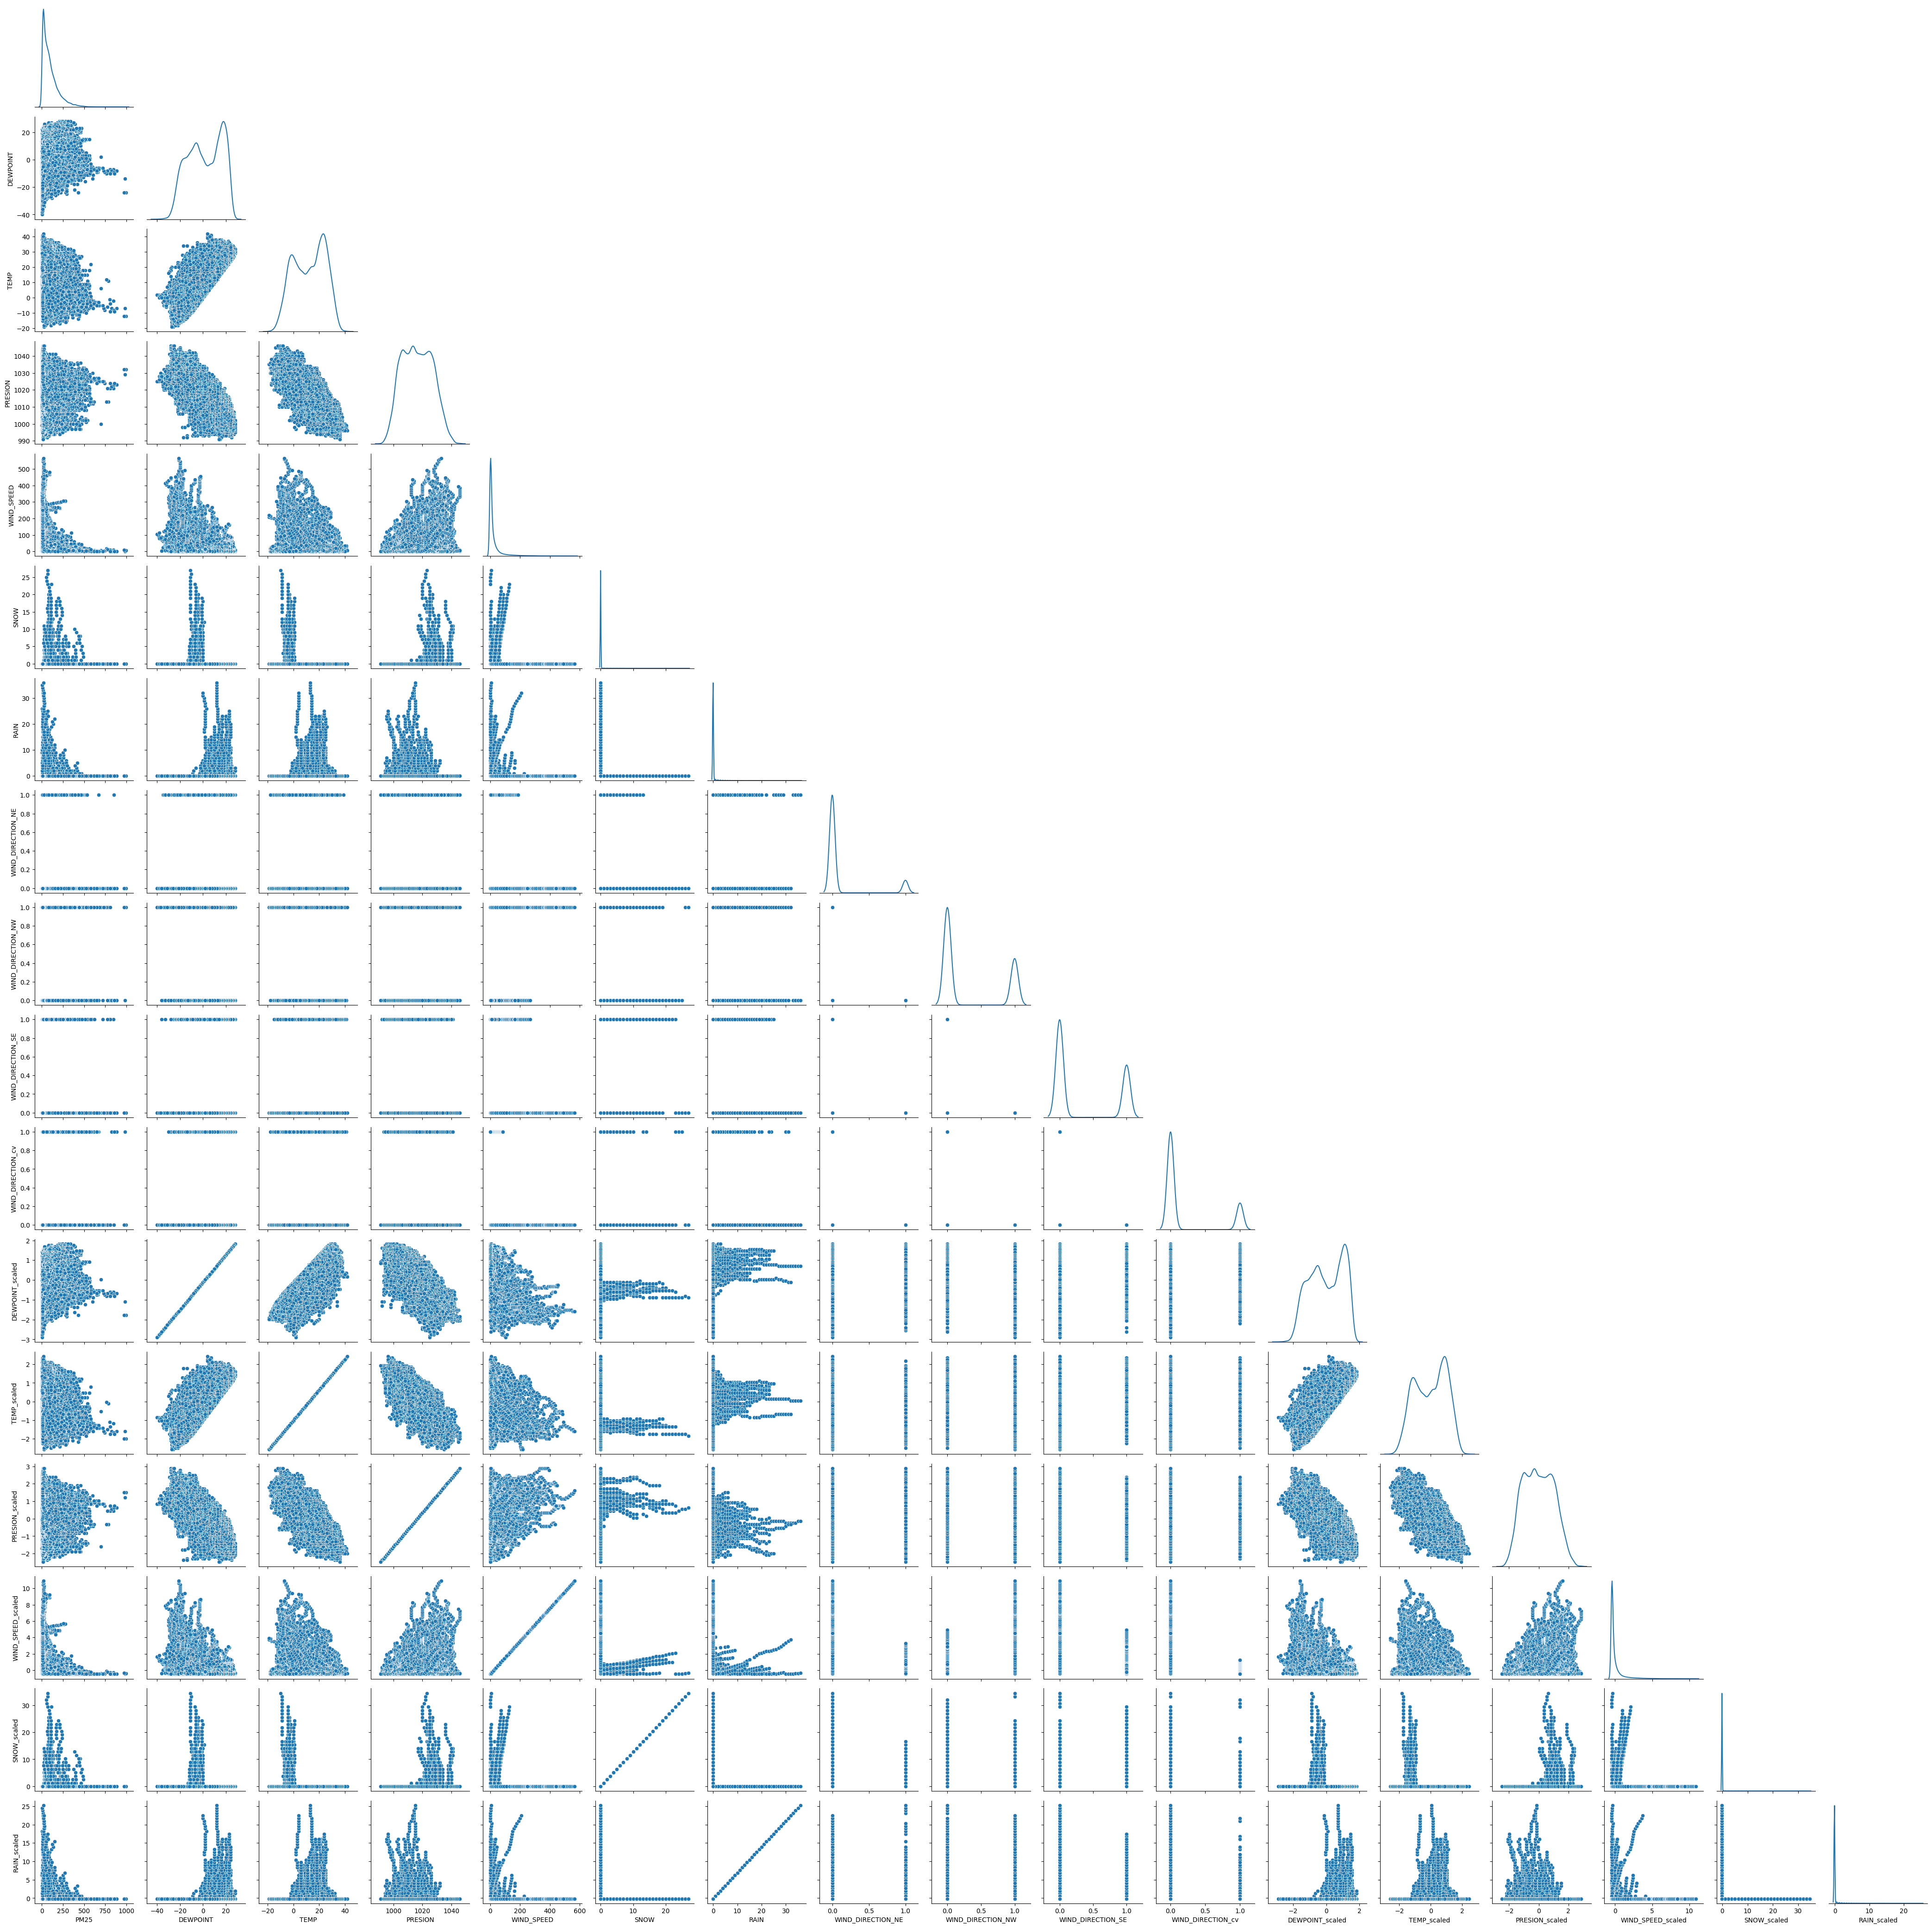

In [ ]:
# Crear figura con tamaño controlado
plt.figure(figsize=(10, 6))   # ajusta ancho y alto según

g = sns.PairGrid(
    df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN", "WIND_DIRECTION_NE", "WIND_DIRECTION_NW", "WIND_DIRECTION_SE", "WIND_DIRECTION_cv",
                           "DEWPOINT_scaled", "TEMP_scaled", "PRESION_scaled", "WIND_SPEED_scaled", "SNOW_scaled", "RAIN_scaled"
              ]],
              diag_sharey=False,
              corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

plt.show()

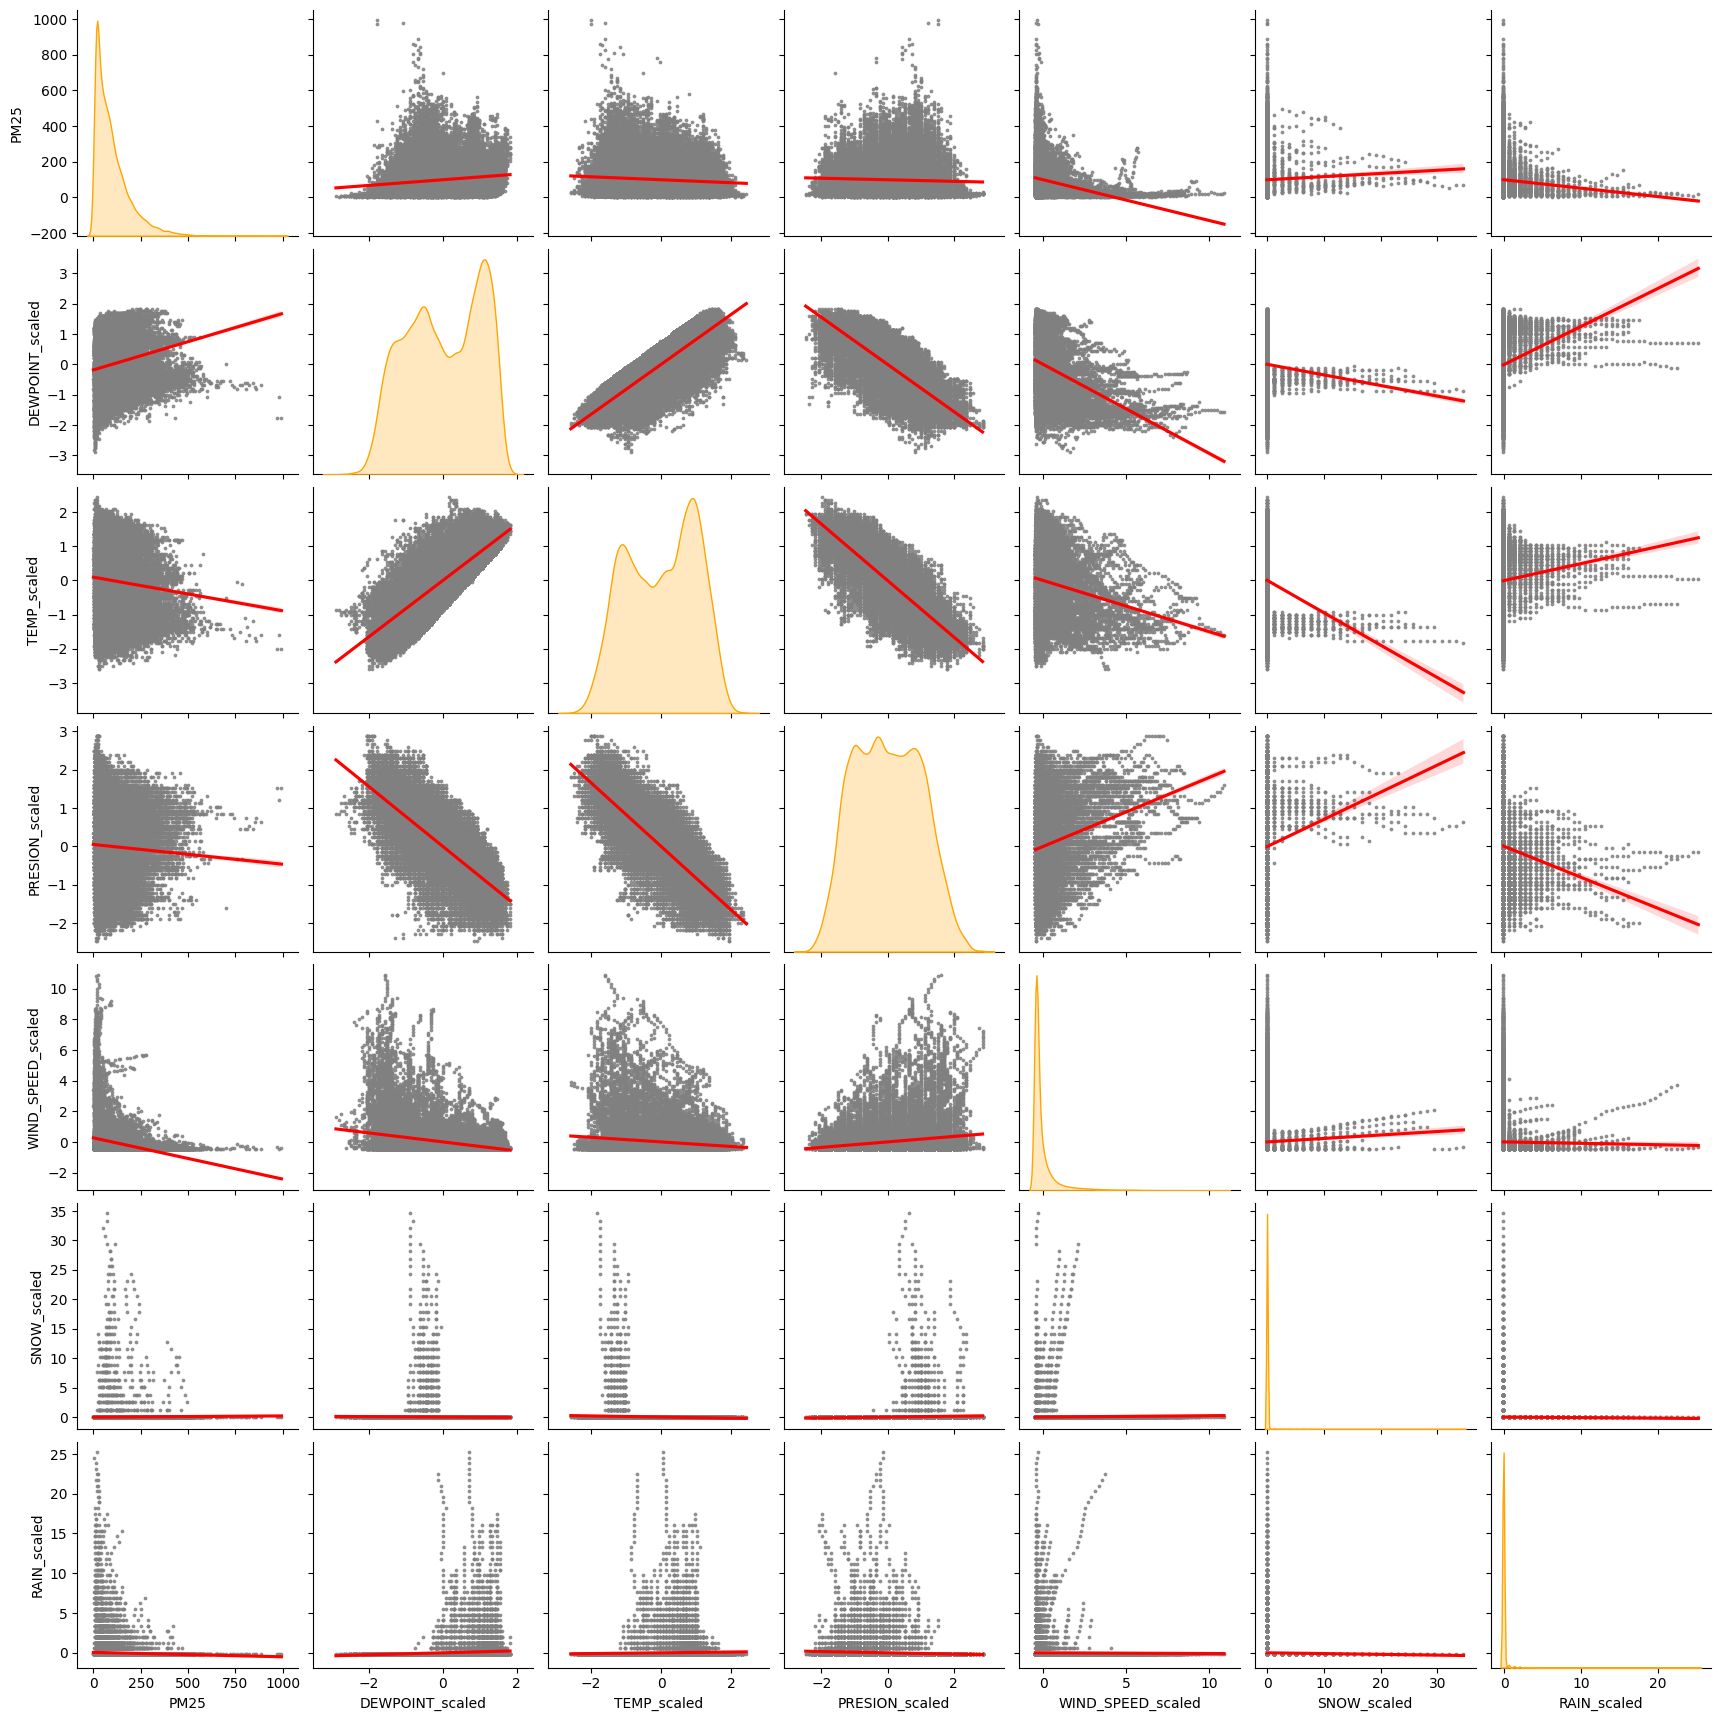

In [ ]:
# Eliminar las columnas que no son para la regresión
# Las gráficas de las columnas escaladas vs las que no lo están son iguales
df_clean_num = df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR", "WIND_DIRECTION", "FECHA", "FECHA_SIN_H"])

df_clean_num_scaled = df_clean_num.drop(columns=["DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN", "WIND_DIRECTION_NE", "WIND_DIRECTION_NW", "WIND_DIRECTION_SE", "WIND_DIRECTION_cv"])

sns.pairplot(
    df_clean_num_scaled,
    diag_kws={"color": "orange"},
    diag_kind='kde',
    kind="reg",
    plot_kws={"scatter_kws":{"color":"grey", "s":3},  "line_kws": {"color": "red"}}
    )
plt.show()

Aquí va el código para los datos imputados con MICE

Modelo en la base de datos PRSA_data_mice_scaled

In [ ]:
# Importar la información  ya limpia y normalizada
df_imputed_mice = pd.read_csv("PRSA_data_mice.csv", sep='\t', encoding='utf-8')

In [ ]:
g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
# llevar a la otra fase
<seaborn.axisgrid.PairGrid at 0x7f6811652f00>


In [ ]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lin_reg.coef_
})

print(coef_df)

Se implementó un modelo de regresión lineal como línea base para evaluar el desempeño inicial. Este modelo permite establecer un punto de comparación para técnicas más complejas

In [ ]:
#Modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
